---
title: "git 教程(2)"
description: "关于git相关的一些教程"
date: 2026-08-24
categories:
  - git
  - Tutorial

format:
  html:
    toc: true
    toc-depth: 3
    code-fold: true
    code-tools: true
---

## 分支管理

Git 分支的作用是让开发者可以在不影响主代码的情况下独立开发新功能。开发者可以创建自己的分支，在分支中随时提交代码，避免代码未完成时影响其他人，也降低了代码丢失的风险。功能完成后，再将分支合并回主分支。

相比 SVN 等版本控制系统，Git 的分支操作速度非常快，创建、切换和删除分支通常都能在 1 秒内完成，因此分支功能在 Git 中更加实用，开发者也更愿意频繁使用。

###  创建与合并分支

在版本回退里，你已经知道，每次提交，Git都把它们串成一条时间线，这条时间线就是一个分支。截止到目前，只有一条时间线，在Git里，这个分支叫主分支，即`master`分支。`HEAD`严格来说不是指向提交，而是指向`master`，`master`才是指向提交的，所以，`HEAD`指向的就是当前分支。

一开始的时候，`master`分支是一条线，Git用`master`指向最新的提交，再用`HEAD`指向`master`，就能确定当前分支，以及当前分支的提交点：

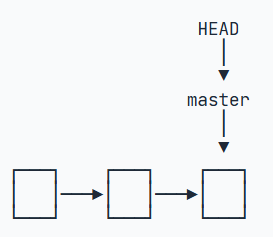


每次提交，`master`分支都会向前移动一步，这样，随着你不断提交，`master`分支的线也越来越长。

当我们创建新的分支，例如`dev`时，Git新建了一个指针叫`dev`，指向`master`相同的提交，再把`HEAD`指向`dev`，就表示当前分支在`dev`上：

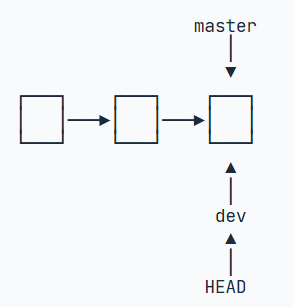

你看，Git创建一个分支很快，因为除了增加一个`dev`指针，改改`HEAD`的指向，工作区的文件都没有任何变化！

不过，从现在开始，对工作区的修改和提交就是针对`dev`分支了，比如新提交一次后，`dev`指针往前移动一步，而`master`指针不变：

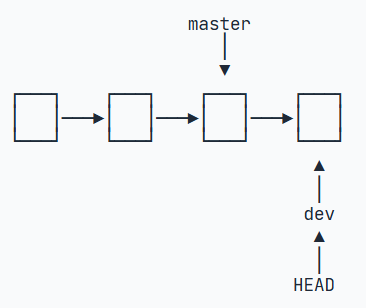

假如我们在`dev`上的工作完成了，就可以把`dev`合并到`master`上。Git怎么合并呢？最简单的方法，就是直接把`master`指向`dev`的当前提交，就完成了合并：

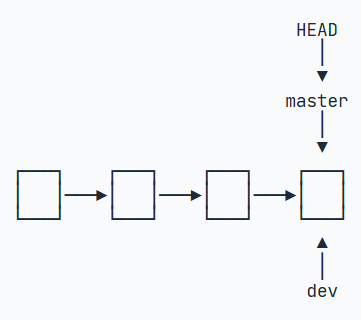

所以Git合并分支也很快！就改改指针，工作区内容也不变！

合并完分支后，甚至可以删除`dev`分支。删除`dev`分支就是把`dev`指针给删掉，删掉后，我们就剩下了一条`master`分支

首先，我们创建`dev`分支，然后切换到`dev`分支：
```bash
$ git checkout -b dev
Switched to a new branch 'dev'
```
`git checkout`命令加上`-b`参数表示创建并切换，相当于以下两条命令：
```bash
$ git branch dev
$ git checkout dev
Switched to branch 'dev'
```

然后，用`git branch`命令查看当前的分支:
```bash
$ git branch
* dev
  master
```


`git branch`命令会列出所有分支，当前分支前面会标一个*号。

然后，我们就可以在`dev`分支上正常提交，比如对`readme.txt`做个修改，加上一行：
```txt
Creating a new branch is quick.
```

然后提交:
```bash
$ git add readme.txt 
$ git commit -m "branch test"
[dev b17d20e] branch test
 1 file changed, 1 insertion(+)
```

现在，`dev`分支的工作完成，我们就可以切换回`master`分支：
```bash
$ git checkout master
Switched to branch 'master'
```

切换回`master`分支后，再查看一个`readme.txt`文件，刚才添加的内容不见了！因为那个提交是在dev分支上，而`master`分支此刻的提交点并没有变：

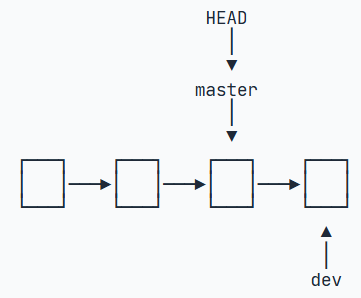

现在，我们把`dev`分支的工作成果合并到`master`分支上：
```bash
$ git merge dev
Updating d46f35e..b17d20e
Fast-forward
 readme.txt | 1 +
 1 file changed, 1 insertion(+)
```
`git merge`命令用于合并指定分支到当前分支。合并后，再查看`readme.txt`的内容，就可以看到，和`dev`分支的最新提交是完全一样的。

注意到上面的`Fast-forward`信息，Git告诉我们，这次合并是“快进模式”，也就是直接把`master`指向`dev`的当前提交，所以合并速度非常快。

当然，也不是每次合并都能`Fast-forward`，我们后面会讲其他方式的合并。

合并完成后，就可以放心地删除dev分支了：
```bash
$ git branch -d dev
Deleted branch dev (was b17d20e).
```
此时查看`branch`，就只剩下`master`：
```bash
$ git branch
* master
```

因为创建、合并和删除分支非常快，所以Git鼓励你使用分支完成某个任务，合并后再删掉分支，这和直接在master分支上工作效果是一样的，但过程更安全。

实际上，切换分支这个动作，用`switch`更科学。因此，最新版本的Git提供了新的`git switch`命令来切换分支：

创建并切换到新的`dev`分支，可以使用：
```bash
$ git switch -c dev
```

直接切换到已有的master分支，可以使用：
```bash
$ git switch master
```

Git鼓励大量使用分支：

查看分支：`git branch`

创建分支：`git branch <name>`

切换分支：`git checkout <name>`或者`git switch <name>`

创建+切换分支：`git checkout -b <name>`或者`git switch -c <name>`

合并某分支到当前分支：`git merge <name>`

删除分支：`git branch -d <name>`

### 解决冲突

准备新的`feature1`分支，继续我们的新分支开发：
```bash
$ git switch -c feature1
Switched to a new branch 'feature1'
```
修改`readme.txt`最后一行，改为：
```txt
Creating a new branch is quick AND simple.
```
在`feature1`分支上提交：
```bash
$ git add readme.txt

$ git commit -m "AND simple"
[feature1 14096d0] AND simple
 1 file changed, 1 insertion(+), 1 deletion(-)
```

切换到`master`分支：
```bash
$ git switch master
Switched to branch 'master'
Your branch is ahead of 'origin/master' by 1 commit.
  (use "git push" to publish your local commits)
```
Git还会自动提示我们当前`master`分支比远程的`master`分支要超前1个提交。

在`master`分支上把`readme.txt`文件的最后一行改为：
```txt
Creating a new branch is quick & simple.
```

提交：
```bash
$ git add readme.txt 
$ git commit -m "& simple"
[master 5dc6824] & simple
 1 file changed, 1 insertion(+), 1 deletion(-)
```

现在，`master`分支和`feature1`分支各自都分别有新的提交，变成了这样：\
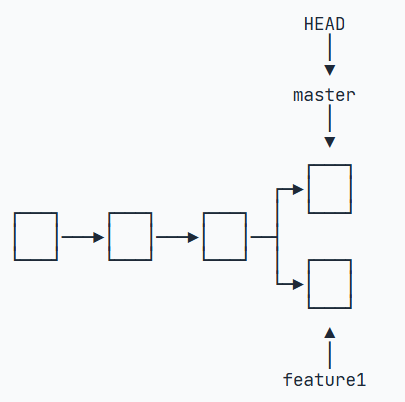

这种情况下，Git无法执行“快速合并”，只能试图把各自的修改合并起来，但这种合并就可能会有冲突，我们试试看：
```bash
$ git merge feature1
Auto-merging readme.txt
CONFLICT (content): Merge conflict in readme.txt
Automatic merge failed; fix conflicts and then commit the result.
```

果然冲突了！Git告诉我们，`readme.txt`文件存在冲突，必须手动解决冲突后再提交。`git status`也可以告诉我们冲突的文件： 
```bash
$ git status
On branch master
Your branch is ahead of 'origin/master' by 2 commits.
  (use "git push" to publish your local commits)

You have unmerged paths.
  (fix conflicts and run "git commit")
  (use "git merge --abort" to abort the merge)

Unmerged paths:
  (use "git add <file>..." to mark resolution)

	both modified:   readme.txt

no changes added to commit (use "git add" and/or "git commit -a")
```

我们可以直接查看readme.txt的内容：
```txt
Git is a distributed version control system.
Git is free software distributed under the GPL.
Git has a mutable index called stage.
Git tracks changes of files.
<<<<<<< HEAD
Creating a new branch is quick & simple.
=======
Creating a new branch is quick AND simple.
>>>>>>> feature1
```

Git用`<<<<<<<`，`=======`，`>>>>>>>`标记出不同分支的内容，我们修改如下后保存：
```txt
Git is a distributed version control system.
Git is free software distributed under the GPL.
Git has a mutable index called stage.
Git tracks changes of files.
Creating a new branch is quick and simple.
```
再提交：
```bash
$ git add readme.txt 
$ git commit -m "conflict fixed"
[master cf810e4] conflict fixed
```

现在就变成了：

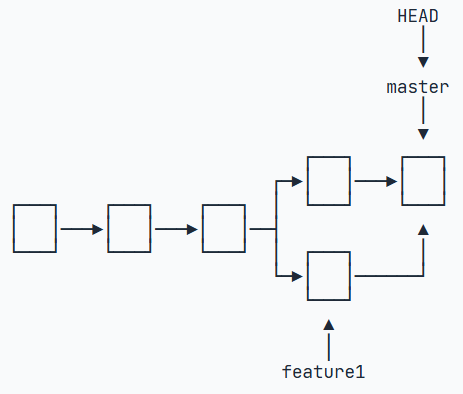

用带参数的`git log`也可以看到分支的合并情况：
```bash
$ git log --graph --pretty=oneline --abbrev-commit
*   cf810e4 (HEAD -> master) conflict fixed
|\  
| * 14096d0 (feature1) AND simple
* | 5dc6824 & simple
|/  
* b17d20e branch test
* d46f35e (origin/master) remove test.txt
* b84166e add test.txt
* 519219b git tracks changes
* e43a48b understand how stage works
* 1094adb append GPL
* e475afc add distributed
* eaadf4e wrote a readme file
```

### 分支管理策略

通常，合并分支时，如果可能，Git会用`Fast forward`模式，但这种模式下，删除分支后，会丢掉分支信息。

如果要强制禁用`Fast forward`模式，Git就会在merge时生成一个新的commit，这样，从分支历史上就可以看出分支信息。

下面我们实战一下`--no-ff`方式的`git merge`：

首先，仍然创建并切换dev分支：
```bash
$ git switch -c dev
Switched to a new branch 'dev'
```
修改`readme.txt`文件，并提交一个新的commit：
```bash
$ git add readme.txt 
$ git commit -m "add merge"
[dev f52c633] add merge
 1 file changed, 1 insertion(+)
```
现在，我们切换回`master`：
```bash
$ git switch master
Switched to branch 'master'
```
准备合并`dev`分支，请注意`--no-ff`参数，表示禁用`Fast forward`：
```bash
$ git merge --no-ff -m "merge with no-ff" dev
Merge made by the 'recursive' strategy.
 readme.txt | 1 +
 1 file changed, 1 insertion(+)
```
因为本次合并要创建一个新的commit，所以加上-m参数，把commit描述写进去。

合并后，我们用`git log`看看分支历史：
```bash
$ git log --graph --pretty=oneline --abbrev-commit
*   e1e9c68 (HEAD -> master) merge with no-ff
|\  
| * f52c633 (dev) add merge
|/  
*   cf810e4 conflict fixed
...
```

我们可以看到，不适用`Fast forward`模型，merge后就像这样：

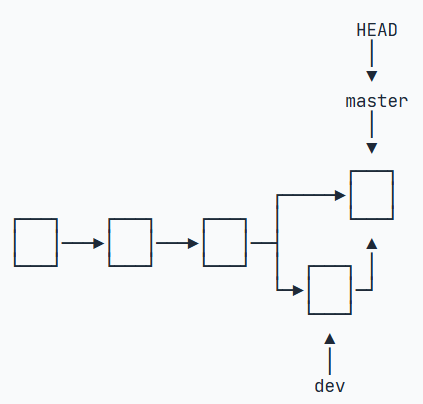

在实际开发中，我们应该按照几个基本原则进行分支管理：

首先，`master`分支应该是非常稳定的，也就是仅用来发布新版本，平时不能在上面干活；

那在哪干活呢？干活都在`dev`分支上，也就是说，dev分支是不稳定的，到某个时候，比如1.0版本发布时，再把`dev`分支合并到`master`上，在`master`分支发布1.0版本；

你和你的小伙伴们每个人都在`dev`分支上干活，每个人都有自己的分支，时不时地往`dev`分支上合并就可以了。

所以，团队合作的分支看起来就像这样：

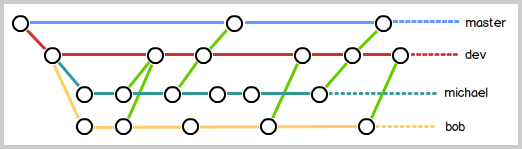

以下一些内容，都不是很重要了，自行探索吧

[Bug分支](https://liaoxuefeng.com/books/git/branch/bug/index.html)

[feature分支](https://liaoxuefeng.com/books/git/branch/feature/index.html)

[多人协作](https://liaoxuefeng.com/books/git/branch/collaboration/index.html)

....

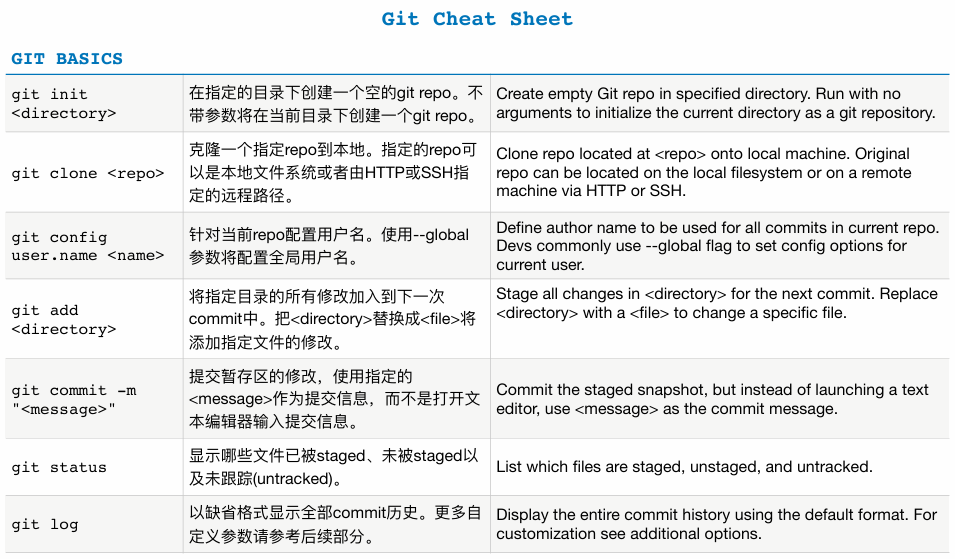

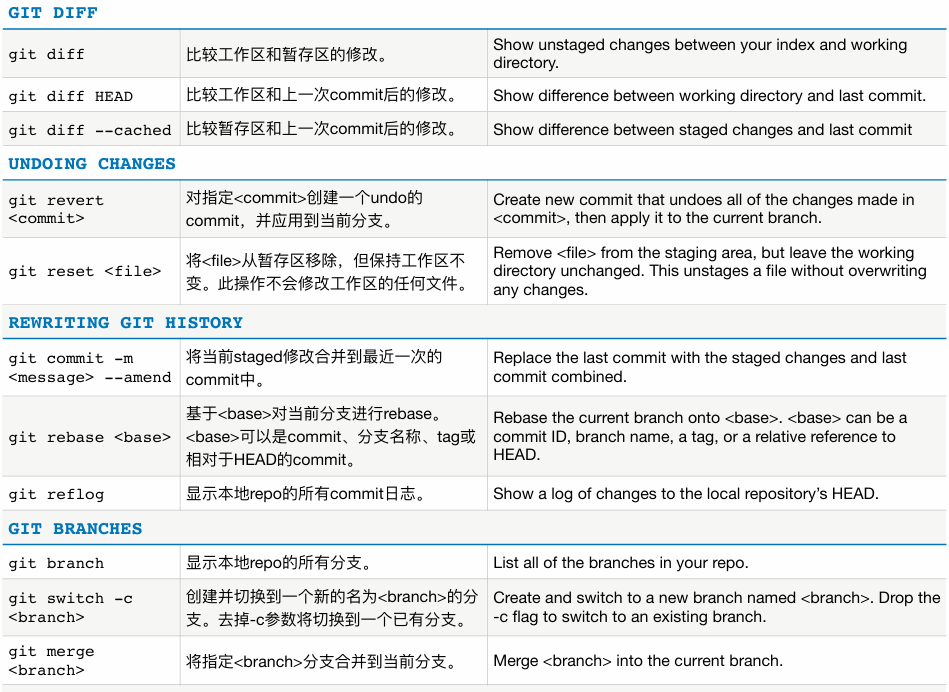

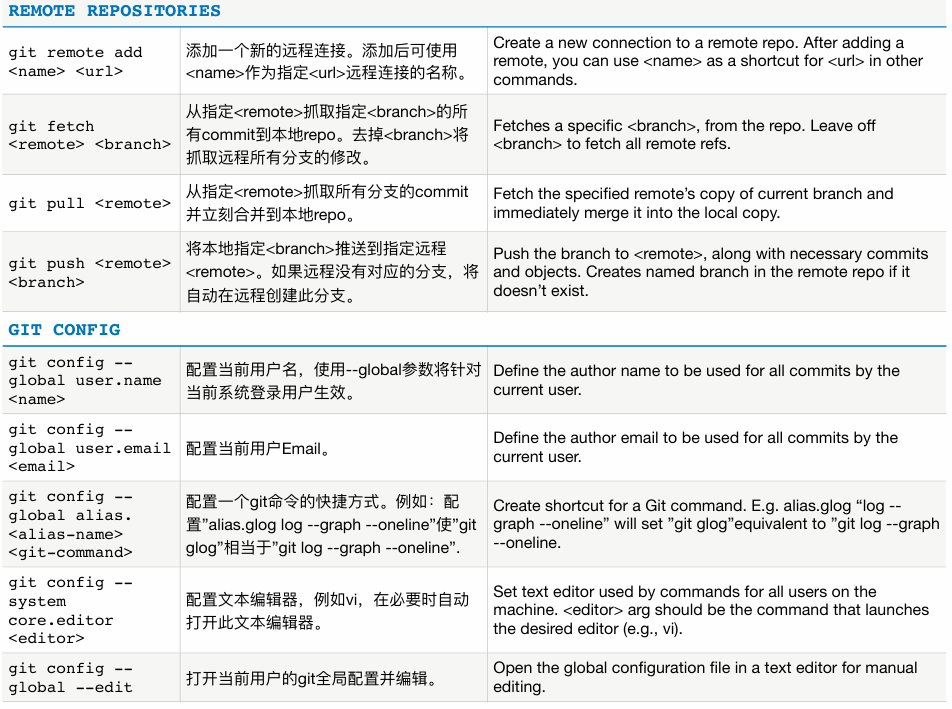

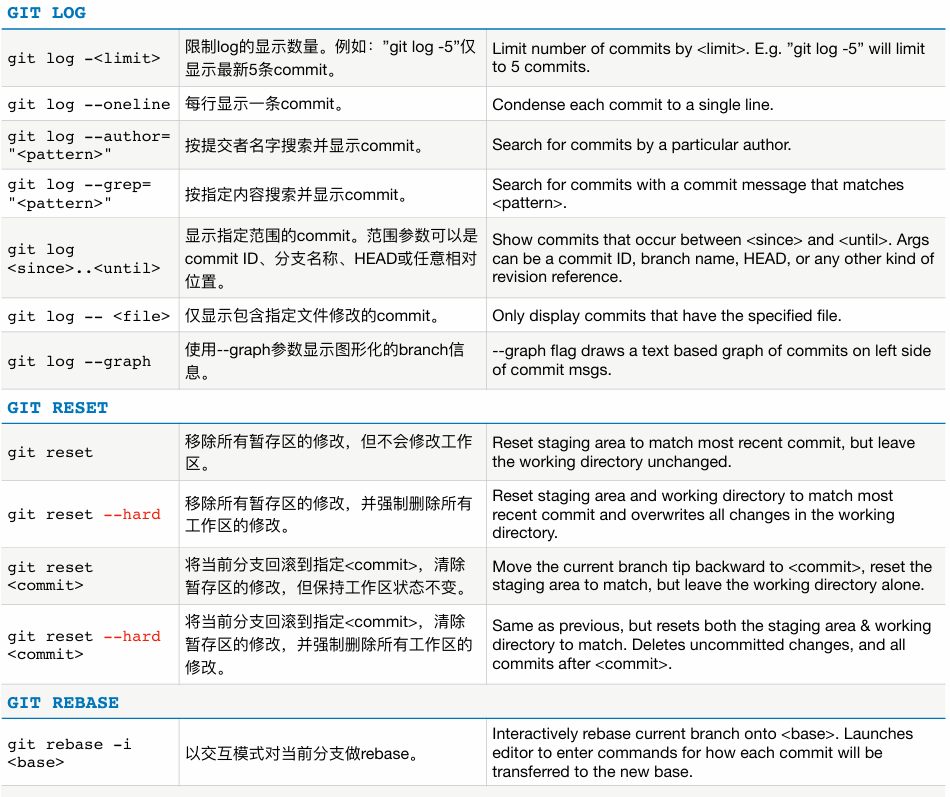

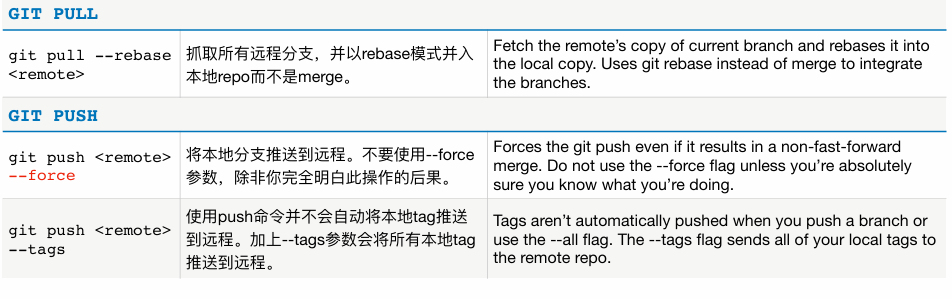